In [2]:
import pandas as pd
df=pd.read_csv(r'/content/cirrhosis.csv')
df

,ID,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [3]:
df.isna().sum()

,0
ID,0
N_Days,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0
Bilirubin,0


In [4]:
columns=['Drug','Ascites','Hepatomegaly','Spiders','Cholesterol','Copper','Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin','Stage']
for i in columns:
  print(i)
  print(df[i].unique())

Drug
['D-penicillamine' 'Placebo' nan]
Ascites
['Y' 'N' nan]
Hepatomegaly
['Y' 'N' nan]
Spiders
['Y' 'N' nan]
Cholesterol
[ 261.  302.  176.  244.  279.  248.  322.  280.  562.  200.  259.  236.
  281.   nan  231.  204.  274.  178.  235.  374.  252.  271.  395.  456.
  298. 1128.  175.  222.  370.  260.  296.  262.  210.  364.  314.  172.
  334.  383.  282.  361.  299.  482.  316.  257.  276.  614.  288.  416.
  498.  242.  329.  604.  216.  932.  373.  256.  427.  466.  174.  652.
  258.  320.  132.  558.  674.  394.  436.  315.  247.  448.  472.  250.
  263. 1600.  345.  408.  660.  325.  206.  353.  201.  420.  239.  460.
  400.  188.  303.  464.  212.  127.  120.  486.  528.  267.  458.  950.
  390.  636.  151.  251.  269.  268. 1775.  331.  578.  399.  426.  328.
  290.  346.  332.  556.  309. 1015.  586.  217.  168.  220.  358.  286.
  450.  317.  502.  233.  196. 1480.  376.  205.  283.  396.  478.  225.
  808.  187.  360. 1092.  308.  293.  347.  226.  266.  392.  223.  149.
  

In [5]:
for i in columns:
  if i in ['Prothrombin', 'SGOT', 'Alk_Phos']:
    df[i]=df[i].fillna(df[i].mean())
  else:
    df[i]=df[i].fillna(df[i].mode()[0])

In [6]:
df.isna().sum()

,0
ID,0
N_Days,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


In [7]:
df.dtypes

,0
ID,int64
N_Days,int64
Drug,object
Age,int64
Sex,object
Ascites,object
Hepatomegaly,object
Spiders,object
Edema,object
Bilirubin,float64


In [39]:
df['Drug'].value_counts()

,count
Drug,
D-penicillamine,264
Placebo,154


In [40]:
df['Sex'].value_counts()

,count
Sex,
F,374
M,44


In [8]:
import seaborn as sns

In [9]:
df.drop(columns='ID',inplace=True)

Is there a significant difference in albumin levels between male and female patients?


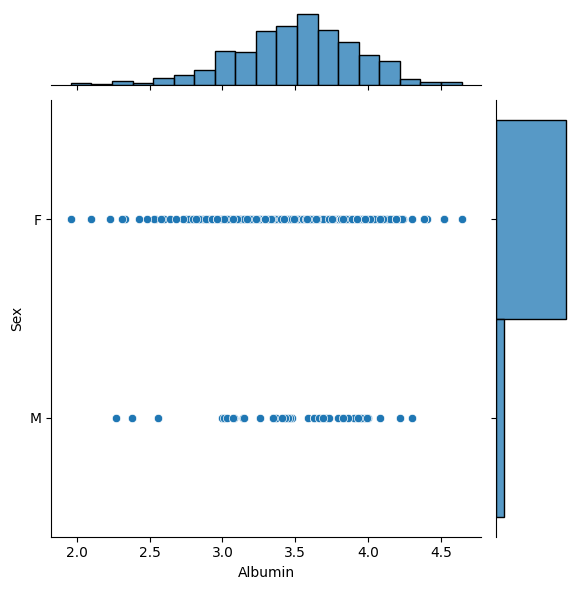

In [41]:
sns.jointplot(x='Albumin',data=df,y='Sex')

Vast difference in Albumin levels can be seen between male and female with females having higher levels.

How do different Stages of cirrhosis relate to Prothrombin levels?

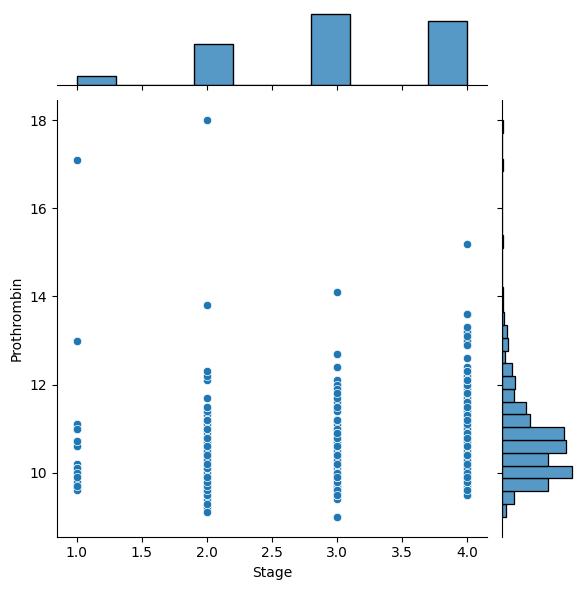

In [16]:
sns.jointplot(x='Stage',y='Prothrombin',data=df)

Prothrombin and Stages of Cirrhosis is in a positive correlation

Q. Compare survival time (N_Days) between patients treated with D-penicillamine vs. Placebo.

<Axes: xlabel='N_Days', ylabel='Count'>

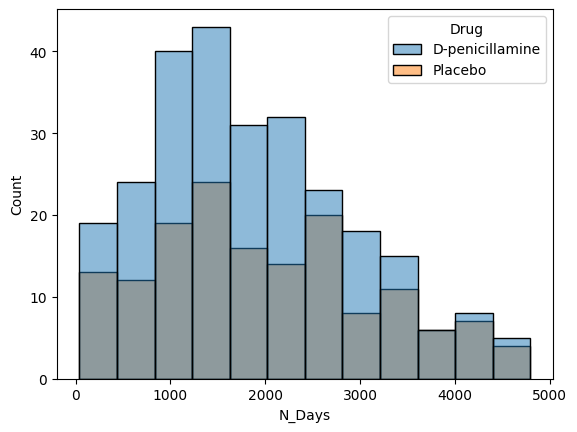

In [22]:
sns.histplot(x='N_Days',data=df,hue='Drug')

D-Pencillamine shows better result than Placebo

What is the average Copper level for each Stage of cirrhosis?

In [38]:
df.groupby('Stage')['Copper'].mean()

,Copper
Stage,
1.0,60.238095
2.0,63.500000
3.0,81.869565
4.0,108.326389
